In [1]:
from dotenv import load_dotenv
from env_utils import doublecheck_env,doublecheck_pkgs

# Load environment variables from .env file

load_dotenv()

#Check environment variables and packages
doublecheck_env(".env.example")
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)

OPENROUTER_API_KEY=****bfed
MODEL_NAME=****tile
GROQ_API_KEY=****OUtX
LANGSMITH_API_KEY=****0b80
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ents
Python 3.11.9 satisfies requires-python: >=3.11
package              | required | installed | status | path                                                           
-------------------- | -------- | --------- | ------ | ---------------------------------------------------------------
langchain            | >=0.3    | 1.3.14    | ✅ OK   | c:\Users\himan\Desktop\Langchain-agents\.venv\Lib\site-packages
langchain-core       | >=0.3    | 1.5.1     | ✅ OK   | c:\Users\himan\Desktop\Langchain-agents\.venv\Lib\site-packages
langchain-community  | >=0.3    | 0.4.2     | ✅ OK   | c:\Users\himan\Desktop\Langchain-agents\.venv\Lib\site-packages
langchain-openai     | >=0.2    | 1.4.1     | ✅ OK   | c:\Users\himan\Desktop\Langchain-agents\.venv\Lib\site-packages
langchain-openrouter | >=0.2.7  | 0.2.7     | ✅ OK   | c:\Users\himan\Desktop\Langchain-age

In [3]:
# Build  a SQl agents
#import the SQLDatabase class from langchain_community.utilities and create an instance of it using the from_uri method, passing in the URI for the SQLite database "Chinook.db". This will allow you to interact with the database using SQL queries.
from langchain_community.utilities import SQLDatabase

# loading the SQLite database "Chinook.db" using the SQLDatabase class from langchain_community.utilities
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

C:\Users\himan\AppData\Local\Temp\ipykernel_4224\282456511.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


In [4]:
# Defining the runtime context to provide the agent and tool with acces to the database

from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase

#define context structure to support the dependency injection of the database into the agent and tool. This will allow the agent and tool to access the database and perform SQL queries as needed.
@dataclass
class RuntimeContext:
    db: SQLDatabase


In [5]:
from  langchain_core.tools import tool
from langgraph.runtime import get_runtime


# Define a custom tool that will allow the agent to execute SQL queries against the database. The tool will take a query string as input and return the results of the query.

@tool
def execute_sql_query(query: str) -> str:
    """" Ececute a SQL query against the database and return the results as a string."""
    
    # Get the runtime context and access the database instance  
    runtime=get_runtime(RuntimeContext)
    db=runtime.context.db
    
    # Execute the SQL query using the database instance and return the results as a string. If an error occurs during query execution, return an error message.
    try:
        return db.run(query)
    except Exception as e:
            return f"Error executing query: {e}"

In [6]:


SYSTEM_PROMPT ="""You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, use the `execute_sql_query` tool with ONE SELECT query. Do NOT output function calls as text - use the actual tool.\n
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

In [7]:
# Create agent using the SQLDatabase instance and the SYSTEM_PROMPT defined above. The agent will use the execute_sql_query tool to interact with the database and retrieve data as needed.

import os
from langchain.agents import create_agent
from langchain_openrouter import ChatOpenRouter
from langchain_groq import ChatGroq


llm1= ChatOpenRouter(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=os.environ["OPENROUTER_API_KEY"],
    timeout=120,
)

llm2= ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.environ["GROQ_API_KEY"],
    timeout=120,
)
agent = create_agent(
    model=llm2,
    tools=[execute_sql_query],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

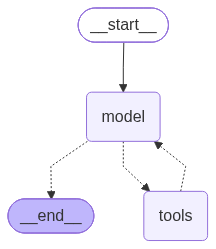

In [8]:
from IPython.display import display,Image

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [9]:
question ="Which table has the largest number of entries?"

# agent.stream() method to execute the question against the agent and stream the results back to the user. The context parameter is used to provide the agent with access to the database instance, and the stream_mode parameter is set to "values" to return only the values of the messages in the response.
for step in agent.stream(
    {"messages":question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    # Print the last message in the step's messages list using the pretty_print() method. This will display the output of the agent's response to the user's question in a readable format.
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql_query (t6c2bjskb)
 Call ID: t6c2bjskb
  Args:
    query: SELECT tbl_name, COUNT(*) as count FROM sqlite_master AS m LEFT JOIN (SELECT name, rowid FROM pragma_table_info('sqlite_master')) AS t ON m.name = t.name GROUP BY tbl_name ORDER BY count DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql_query

[('Track', 4)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql_query (rxdmgwtwe)
 Call ID: rxdmgwtwe
  Args:
    query: SELECT name, rowid FROM pragma_table_info('Track') LIMIT 5;
================================= Tool Message =================================
Name: execute_sql_query

[('TrackId', 1), ('Name', 2), ('AlbumId', 3), ('MediaTy

In [10]:
question ="Which table has the lowest number of entries?"

# agent.stream() method to execute the question against the agent and stream the results back to the user. The context parameter is used to provide the agent with access to the database instance, and the stream_mode parameter is set to "values" to return only the values of the messages in the response.
for step in agent.stream(
    {"messages":question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    # Print the last message in the step's messages list using the pretty_print() method. This will display the output of the agent's response to the user's question in a readable format.
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the lowest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql_query (mc2nbdnpd)
 Call ID: mc2nbdnpd
  Args:
    query: SELECT TABLE_NAME, COUNT(*) as count FROM sqlite_master WHERE type='table' GROUP BY TABLE_NAME ORDER BY count ASC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql_query

Error executing query: (sqlite3.OperationalError) no such column: TABLE_NAME
[SQL: SELECT TABLE_NAME, COUNT(*) as count FROM sqlite_master WHERE type='table' GROUP BY TABLE_NAME ORDER BY count ASC LIMIT 1;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  execute_sql_query (nzf1rhncd)
 Call ID: nzf1rhncd
  Args:
    query: SELECT name, (SELECT COUNT(*) FROM sqlite_maste

In [11]:
question ="Please provide the names of all the tables in the database ?"

# agent.stream() method to execute the question against the agent and stream the results back to the user. The context parameter is used to provide the agent with access to the database instance, and the stream_mode parameter is set to "values" to return only the values of the messages in the response.
for step in agent.stream(
    {"messages":question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    # Print the last message in the step's messages list using the pretty_print() method. This will display the output of the agent's response to the user's question in a readable format.
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please provide the names of all the tables in the database ?
================================== Ai Message ==================================
Tool Calls:
  execute_sql_query (220k9dw9t)
 Call ID: 220k9dw9t
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql_query

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

The database contains the following tables: 

1. Album
2. Artist
3. Customer
4. Employee
5. Genre
6. Invoice
7. InvoiceLine
8. MediaType
9. Playlist
10. PlaylistTrack
11. Track 

These tables appear to be related to a music database, possibly for an online music store or streaming service.
